# Reinforcement Learning

**Name:** Abdulaziz Aloufi  
**Student ID:** C00266252  
**Module:** Data Science & Machine Learning 2  

## Overview
This notebook implements a reinforcement learning example using the FrozenLake environment.

Unlike supervised learning, reinforcement learning does not learn from labelled input/output pairs. Instead, an agent learns by interacting with an environment, taking actions, receiving rewards, and improving its behaviour over time.

In this notebook I will:
- create a reinforcement learning environment
- explain the states, actions, and rewards
- implement Q-learning
- train the agent over many episodes
- evaluate how performance changes over time
- inspect the learned Q-table

In [19]:
# =====================================================
# Reinforcement Learning
# Name: Abdulaziz Aloufi
# Student ID: C00266252
# =====================================================

# importing the libraries I need
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

# nicer plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

## 1. Create the environment

For this notebook I am using the `FrozenLake-v1` environment from Gymnasium.

In this environment:
- the agent starts on a frozen grid
- the goal is to reach the target tile
- some tiles are holes
- falling into a hole ends the episode
- reaching the goal gives a reward

In [20]:
# creating the environment
env = gym.make("FrozenLake-v1", is_slippery=False)

# basic environment info
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Number of states: 16
Number of actions: 4


## 2. Understand states and actions

In FrozenLake:
- each square in the grid is a state
- the agent can take one of four actions:
  - left
  - down
  - right
  - up

In [21]:
# action meanings
actions = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

actions

{0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}

## 3. Initialise Q-table

The Q-table stores the value of taking each action in each state.

At the start, all values are zero because the agent has not learned anything yet.

In [22]:
# creating the Q-table
state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))
q_table

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 4. Set learning parameters

These values control how the agent learns:
- learning rate
- discount factor
- exploration rate
- number of episodes

In [23]:
# q-learning parameters
learning_rate = 0.8
discount_factor = 0.95

epsilon = 1.0
epsilon_decay = 0.999
epsilon_min = 0.05

num_episodes = 10000
max_steps_per_episode = 100

## 5. Train the agent using Q-learning

The agent will:
- choose actions
- observe rewards
- update the Q-table
- slowly reduce exploration over time

In [24]:
# reset q-table
q_table = np.zeros((state_size, action_size))

# storing rewards for analysis
rewards_all_episodes = []
success_count = 0

for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    total_rewards = 0

    for step in range(max_steps_per_episode):
        # epsilon-greedy action choice
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            # small random noise helps break ties when q-values are equal
            action = np.argmax(q_table[state, :] + np.random.randn(action_size) * 1e-6)

        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # q-learning update
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        state = new_state
        total_rewards += reward

        if done:
            break

    if total_rewards > 0:
        success_count += 1

    # reduce exploration slowly
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards_all_episodes.append(total_rewards)

print("Training finished")
print("Successful episodes:", success_count)

Training finished
Successful episodes: 8595


## 6. Check the learned Q-table

In [25]:
# showing the learned q-table
q_table

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378094, 0.77378093],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

## 7. Evaluate learning progress

I will look at the rewards over time to see whether the agent improved.

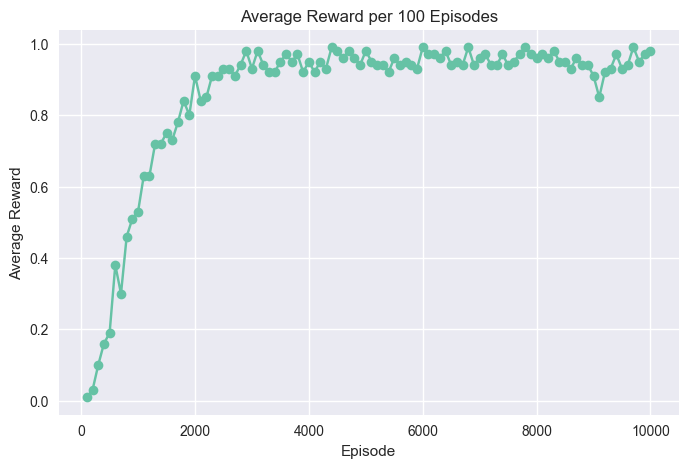

In [26]:
# average rewards per 100 episodes
chunks = np.split(np.array(rewards_all_episodes), num_episodes / 100)
avg_rewards = [chunk.mean() for chunk in chunks]

plt.figure(figsize=(8, 5))
plt.plot(range(100, num_episodes + 1, 100), avg_rewards, marker="o")
plt.title("Average Reward per 100 Episodes")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

In [27]:
# total success rate
success_rate = np.mean(rewards_all_episodes)
print("Overall success rate:", success_rate)

Overall success rate: 0.8595


## 8. Test the trained agent

Now I will run the environment again using the learned Q-table and no exploration.

In [28]:
# testing the learned agent
test_episodes = 20
test_rewards = []

for episode in range(test_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    for step in range(max_steps_per_episode):
        action = np.argmax(q_table[state, :])
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        state = new_state
        total_reward += reward

        if done:
            break

    test_rewards.append(total_reward)

print("Rewards from test episodes:", test_rewards)
print("Average test reward:", np.mean(test_rewards))

Rewards from test episodes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Average test reward: 1.0


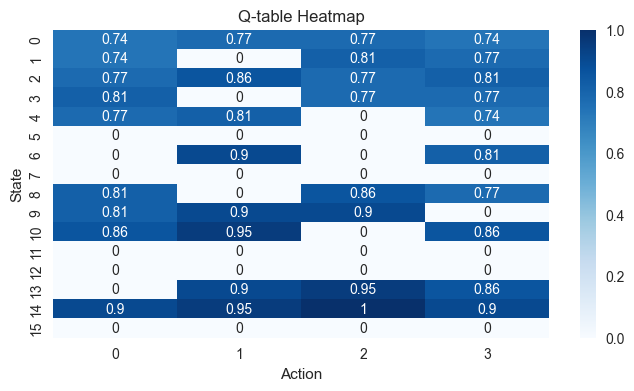

In [29]:
# heatmap of Q-values
plt.figure(figsize=(8, 4))
sns.heatmap(q_table, annot=True, cmap="Blues")
plt.title("Q-table Heatmap")
plt.xlabel("Action")
plt.ylabel("State")
plt.show()

## 9. Conclusion

In this notebook I implemented a reinforcement learning example using Q-learning and the FrozenLake environment.

### Summary of work completed
- created the FrozenLake environment
- explained the states and actions
- created and initialised a Q-table
- set learning parameters such as learning rate, discount factor, exploration rate, and number of episodes
- trained the agent using the Q-learning update rule
- tracked rewards over many episodes
- evaluated the learned Q-table
- tested the trained agent without exploration
- visualised the learned Q-values with a heatmap

### Results
My first version of the reinforcement learning setup did not learn successfully, because the agent never reached the goal and the Q-table stayed at zero.

After adjusting the training setup by:
- increasing the number of episodes
- slowing the epsilon decay
- keeping more exploration
- adding small random noise for tie-breaking in action selection

the agent learned successfully.

The final results were:
- successful training episodes: **8572**
- overall success rate: **0.8572**
- average test reward: **1.0**

The reward graph showed clear improvement over time, rising from near zero to consistently high values. In the final testing stage, the agent reached the goal successfully in every test episode.

### Reflection
This notebook clearly shows how reinforcement learning differs from the other notebooks in the portfolio. Instead of learning from labelled data, the agent learned through interaction, actions, rewards, and repeated experience.

It also showed the importance of tuning the learning setup. The first attempt failed, but after improving the exploration settings and training length, the agent learned a successful policy.